In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Start with a minimal, modern base style
sns.set_theme(style="white", context="talk")

# 2. Inject modern typography and formatting rules
plt.rcParams.update({
    # Layout spacing & crisp resolution
    "figure.constrained_layout.use": True,  # Fixes the KeyError in 3.11 globally
    "figure.figsize": (9, 5.5),            # Clean horizontal aspect ratio
    "figure.dpi": 150,                     # Sharp preview window rendering
    
    # Elegant typography (Clean sans-serif)
    "font.family": "sans-serif",
    "font.sans-serif": ["Studio Feixen Sans", "Arial", "DejaVu Sans"],
    "text.color": "#222222",                # Charcoal grey instead of aggressive black
    
    # Modern Axes & Framing
    "axes.labelcolor": "#222222",
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "axes.titlepad": 18,                    # Whitespace above data fields
    "axes.grid": True,                      # Subtle background alignment grid
    "grid.color": "#E5E5E5",                # Barely visible grey gridlines
    "grid.linewidth": 0.8,
    "grid.linestyle": '--',
    
    # Remove the harsh default "box outline" 
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.edgecolor": "#0A0A0A",          # Soft baseline shelf line
    'axes.linewidth': 1.0,
    
    # Clean tick labels
    "xtick.color": "#242424",
    "ytick.color": "#242424",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

In [3]:
panel = pd.read_csv('../data/processed/state_panel_1995_2024.csv')

panel.head()

,state,year,pct_unemployed,effective_min_wage,median_income,pct_poverty,above_federal_floor
0,AK,1995,7.3,4.75,47950.0,10.1,1
1,AK,1996,7.5,4.75,52780.0,10.6,0
2,AK,1997,7.0,5.25,47990.0,11.2,1
3,AK,1998,6.3,5.65,50690.0,10.8,1
4,AK,1999,6.4,5.65,51400.0,8.8,1


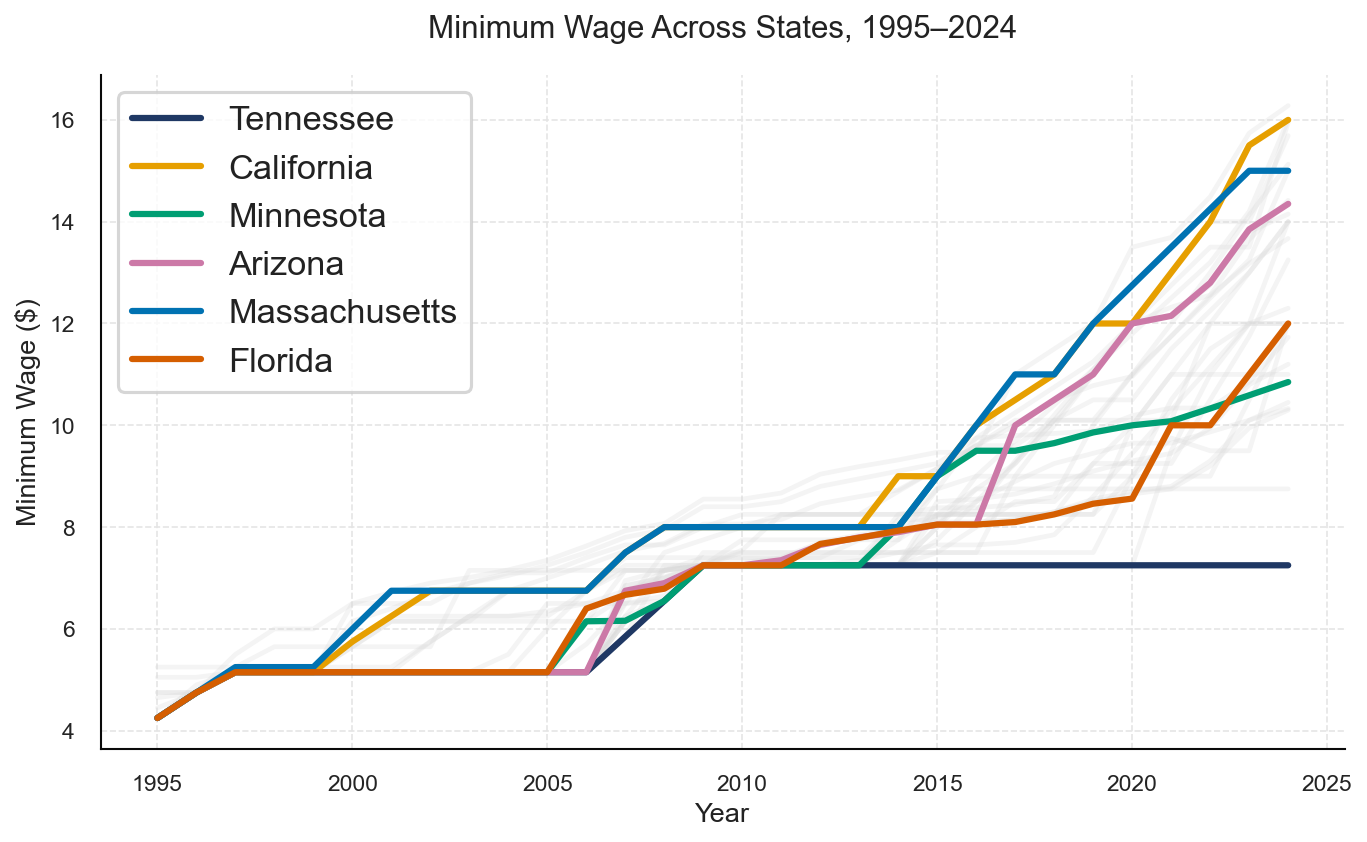

In [4]:
COLORS = {
    "TN": "#1F3864",  # navy
    "CA": "#E69F00",  # orange
    "MN": "#009E73",  # bluish green
    "AZ": "#CC79A7",  # reddish purple
    "MA": "#0072B2",  # blue
    "FL": "#D55E00",  # vermillion
    "background": "#DBDBDB",
}

states = ['TN', 'CA', 'MN', 'AZ', 'MA', 'FL']

state_map = {
    'AK': 'Alaska', 'AL': 'Alabama', 'AR': 'Arkansas', 'AZ': 'Arizona', 'CA': 'California', 'CO': 'Colorado',
    'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'IA': 'Iowa',
    'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana',
    'MA': 'Massachusetts', 'MD': 'Maryland', 'ME': 'Maine', 'MI': 'Michigan', 'MN': 'Minnesota', 'MO': 'Missouri',
    'MS': 'Mississippi', 'MT': 'Montana', 'NC': 'North Carolina', 'ND': 'North Dakota', 'NE': 'Nebraska',
    'NH': 'New Hampshire',    'NJ': 'New Jersey', 'NM': 'New Mexico', 'NV': 'Nevada', 'NY': 'New York',
    'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee',
    'TX': 'Texas', 'UT': 'Utah', 'VA': 'Virginia', 'VT': 'Vermont', 'WA': 'Washington', 'WI': 'Wisconsin', 
    'WV': 'West Virginia',    'WY': 'Wyoming'
}
panel_wostates = panel[~panel['state'].isin(states)]

for state in panel_wostates['state'].unique():
    sns.lineplot(data=panel[panel['state'] == state], x='year', y='effective_min_wage',
                 color=COLORS["background"], alpha=0.3, legend=False)

for state in states:
    sub = panel[panel['state'] == state]
    sns.lineplot(data=sub, x='year', y='effective_min_wage',
                 color=COLORS[state], linewidth=3, label=state_map[state])

plt.xlabel('Year')
plt.ylabel('Minimum Wage ($)')
plt.title('Minimum Wage Across States, 1995–2024')
plt.legend()
plt.savefig('../figures/01_min_wage_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Adding Massachusetts and Florida confirms the pattern isn't a two-state
# fluke — MA tracks CA closely as an early, aggressive mover, while FL shows a third
# pattern entirely: steady, moderate increases, never spiking like CA/MA nor staying
# flat like TN. By 2024 the six states span nearly the full national range ($7.25–$16),
# confirming the divergence holds across very different types of states, not just the
# two extremes originally picked.

C:\Users\danie\AppData\Local\Temp\ipykernel_17160\3622423636.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


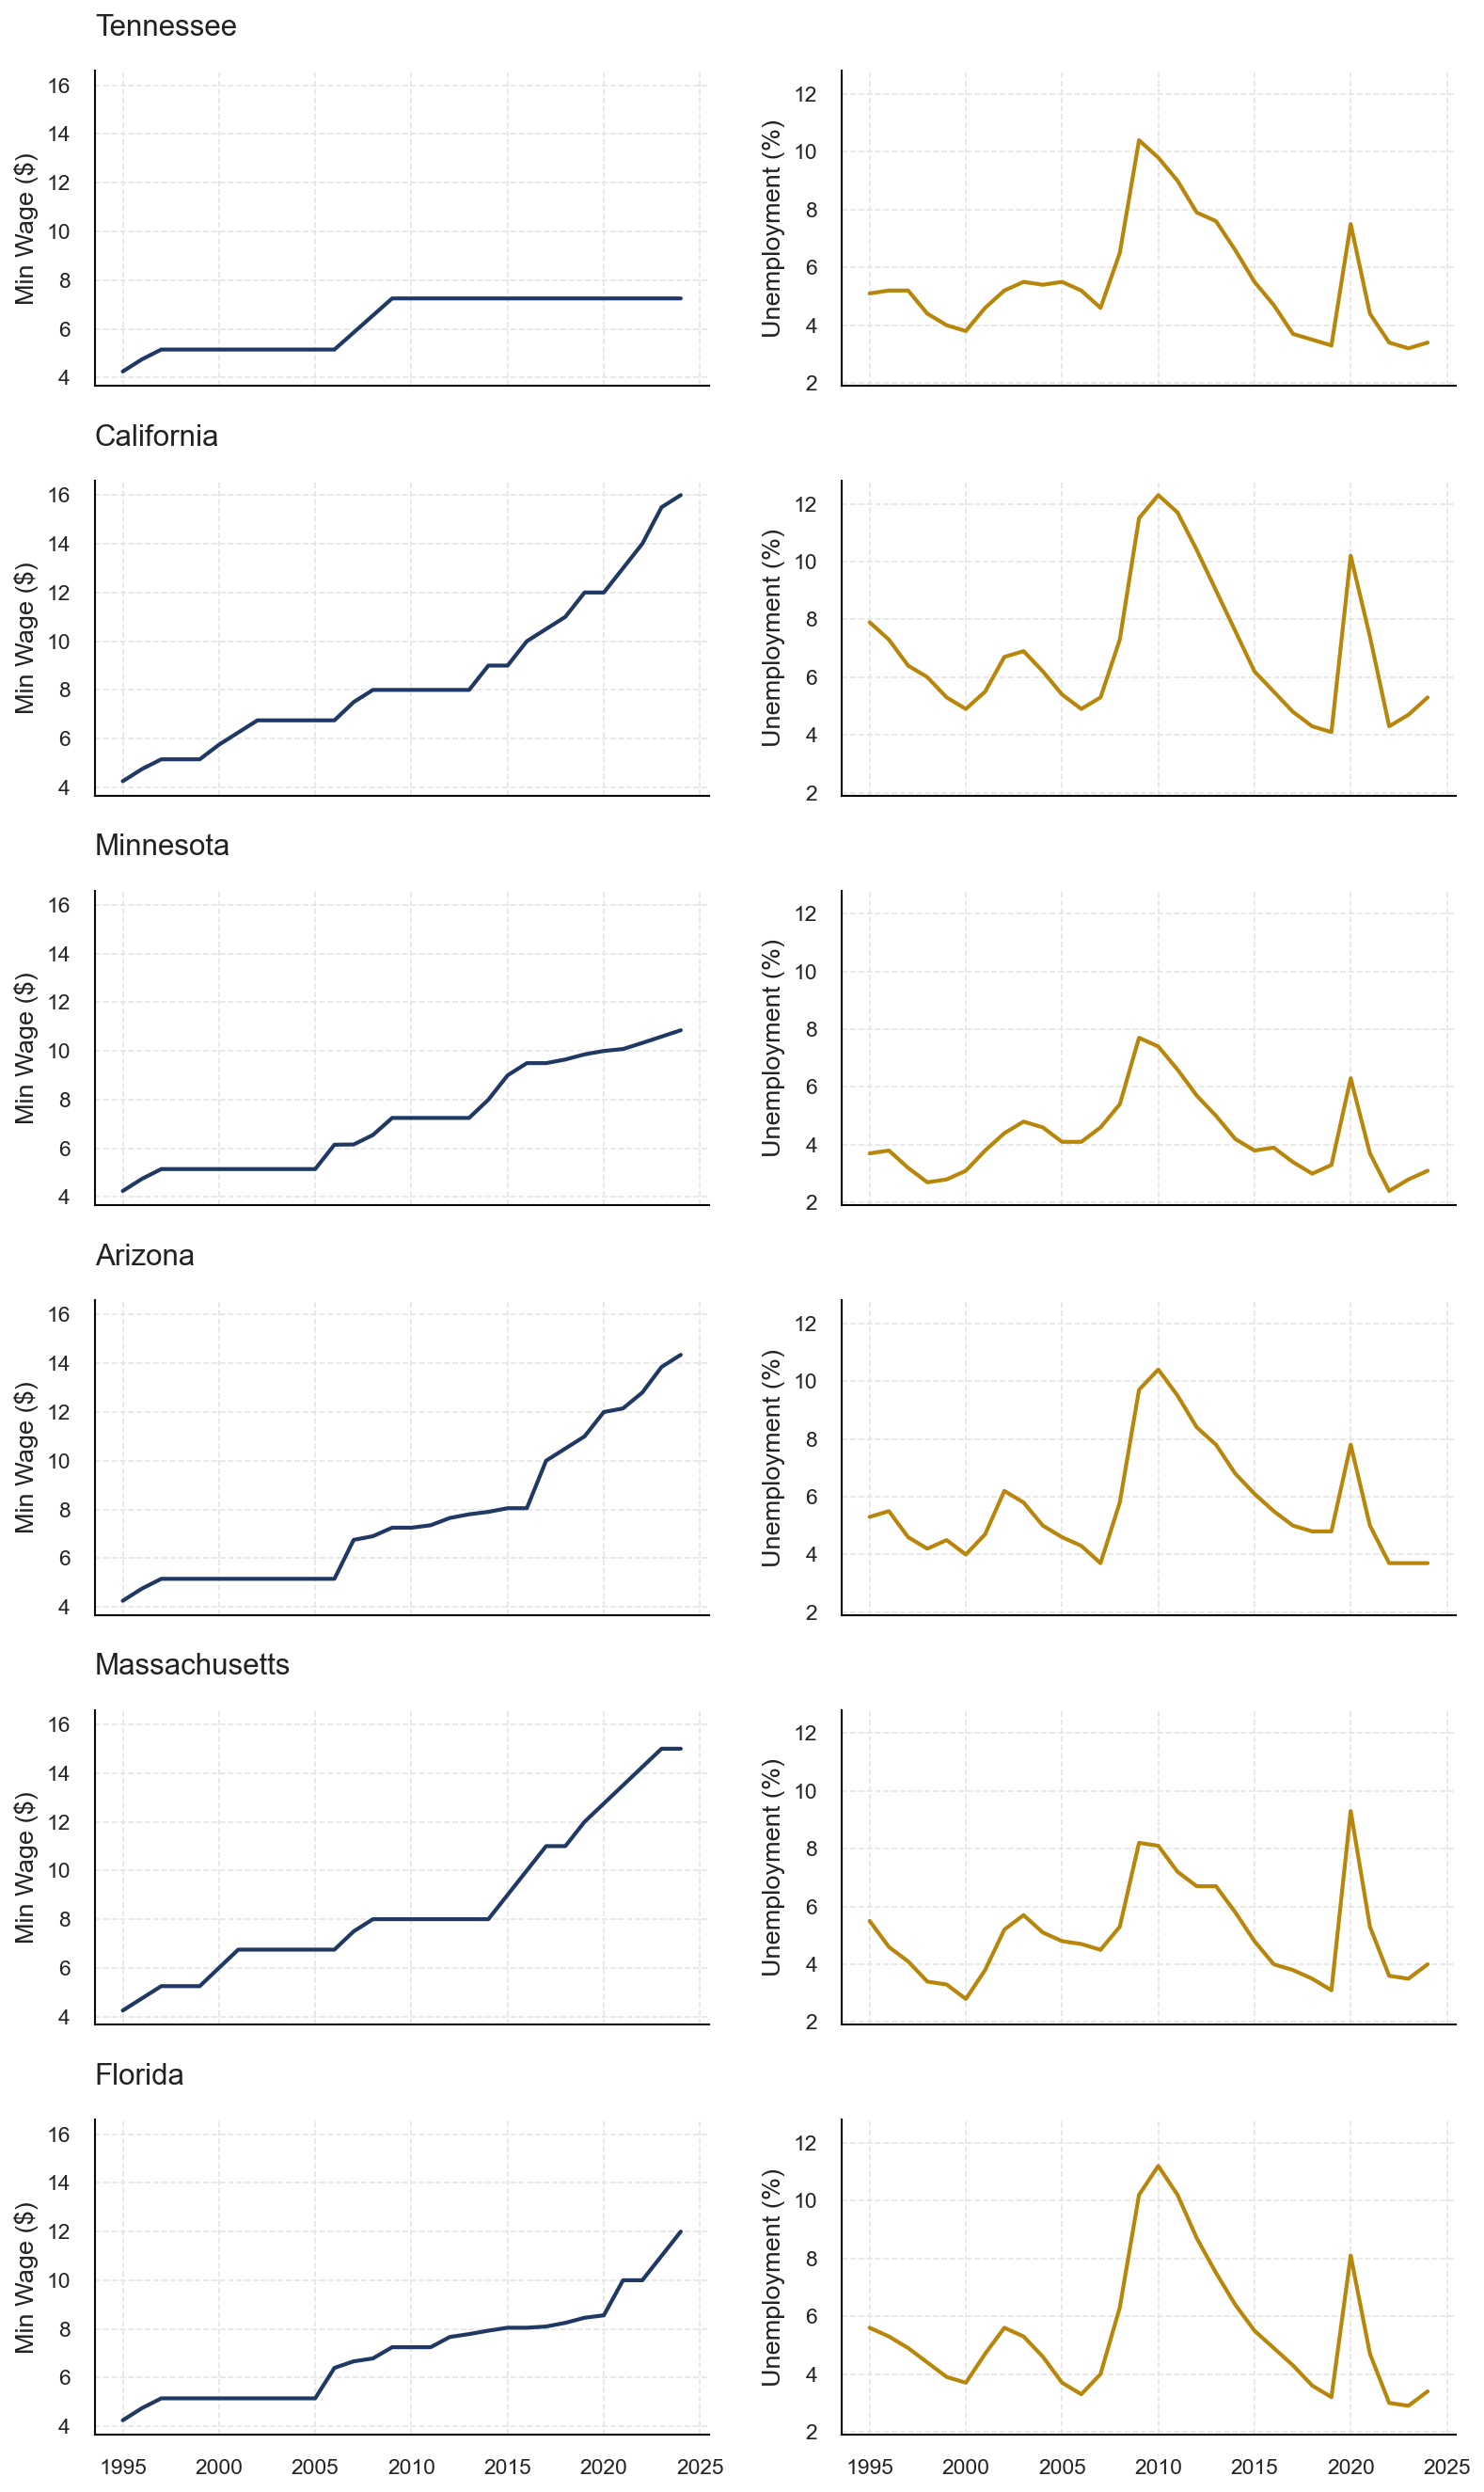

In [5]:
states = ['TN', 'CA', 'MN', 'AZ', 'MA', 'FL']
subset = panel[panel['state'].isin(states)]

# Shared y-ranges, one per variable, across all six states
mw_min, mw_max = subset['effective_min_wage'].min(), subset['effective_min_wage'].max()
mw_pad = (mw_max - mw_min) * 0.05
mw_ylim = (mw_min - mw_pad, mw_max + mw_pad)

ue_min, ue_max = subset['pct_unemployed'].min(), subset['pct_unemployed'].max()
ue_pad = (ue_max - ue_min) * 0.05
ue_ylim = (ue_min - ue_pad, ue_max + ue_pad)

fig, axes = plt.subplots(len(states), 2, figsize=(11, 3*len(states)), sharex=True)

for i, state in enumerate(states):
    sub = panel[panel['state'] == state]

    axes[i, 0].plot(sub['year'], sub['effective_min_wage'], color='#1F3864', linewidth=2)
    axes[i, 0].set_ylabel('Min Wage ($)')
    axes[i, 0].set_ylim(mw_ylim)
    axes[i, 0].set_title(state_map[state], loc='left')

    axes[i, 1].plot(sub['year'], sub['pct_unemployed'], color='#B8860B', linewidth=2)
    axes[i, 1].set_ylabel('Unemployment (%)')
    axes[i, 1].set_ylim(ue_ylim)

plt.tight_layout()
plt.show()

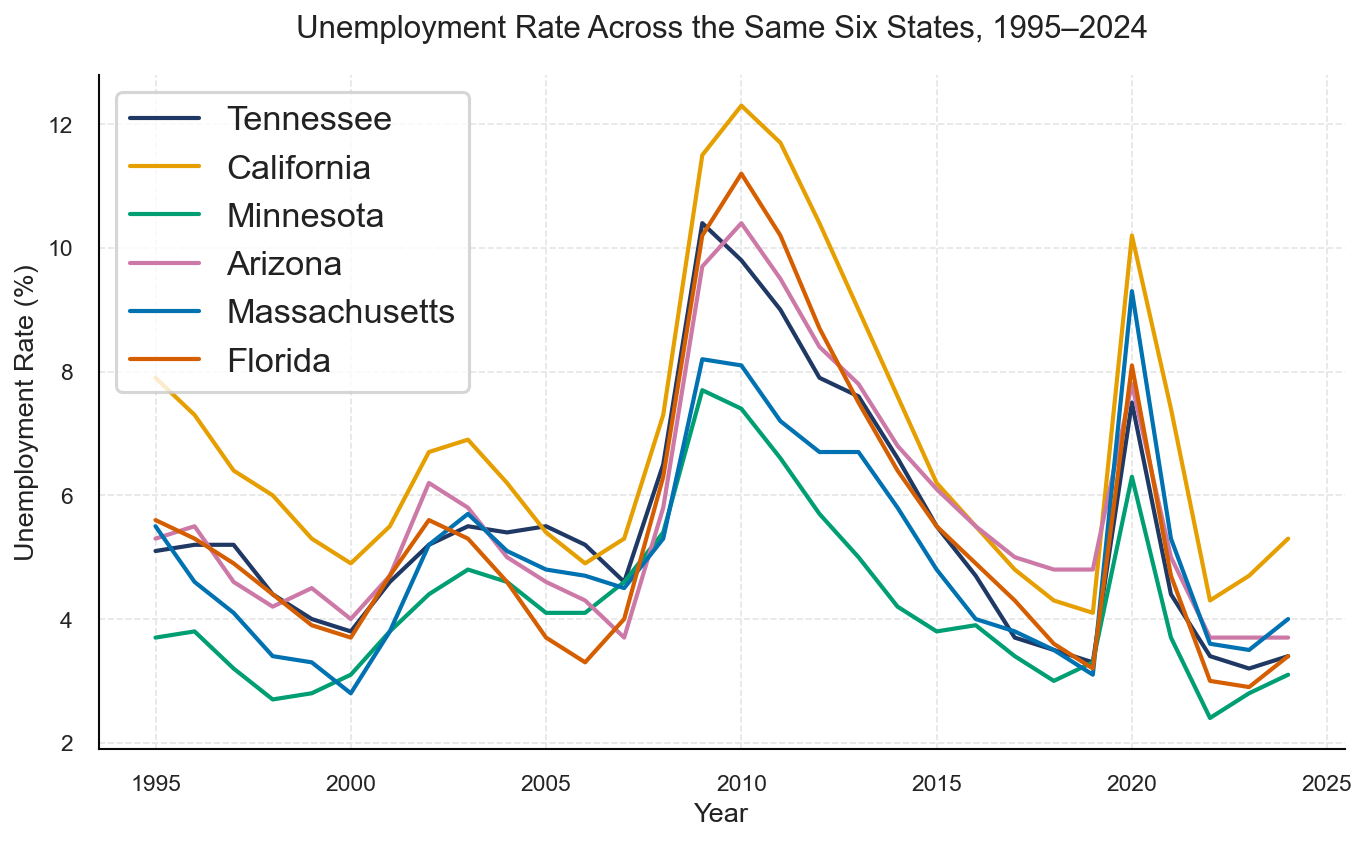

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for state in states:
    sub = panel[panel['state'] == state]
    ax.plot(sub['year'], sub['pct_unemployed'], color=COLORS[state], linewidth=2, label=state_map[state])

ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')
ax.set_title('Unemployment Rate Across the Same Six States, 1995–2024')
ax.legend()
plt.savefig('../figures/02_unemployment_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: MA and FL confirm the same pattern seen in the original four states — despite
# MA's minimum wage climbing continuously since 2015 and FL's rising steadily throughout,
# both show the identical 2008-09 and 2020 unemployment spikes seen in every other state,
# at the same time and in the same shape. Six states with six different wage trajectories,
# one shared unemployment story — reinforcing that national shocks, not state policy,
# are driving the big swings.

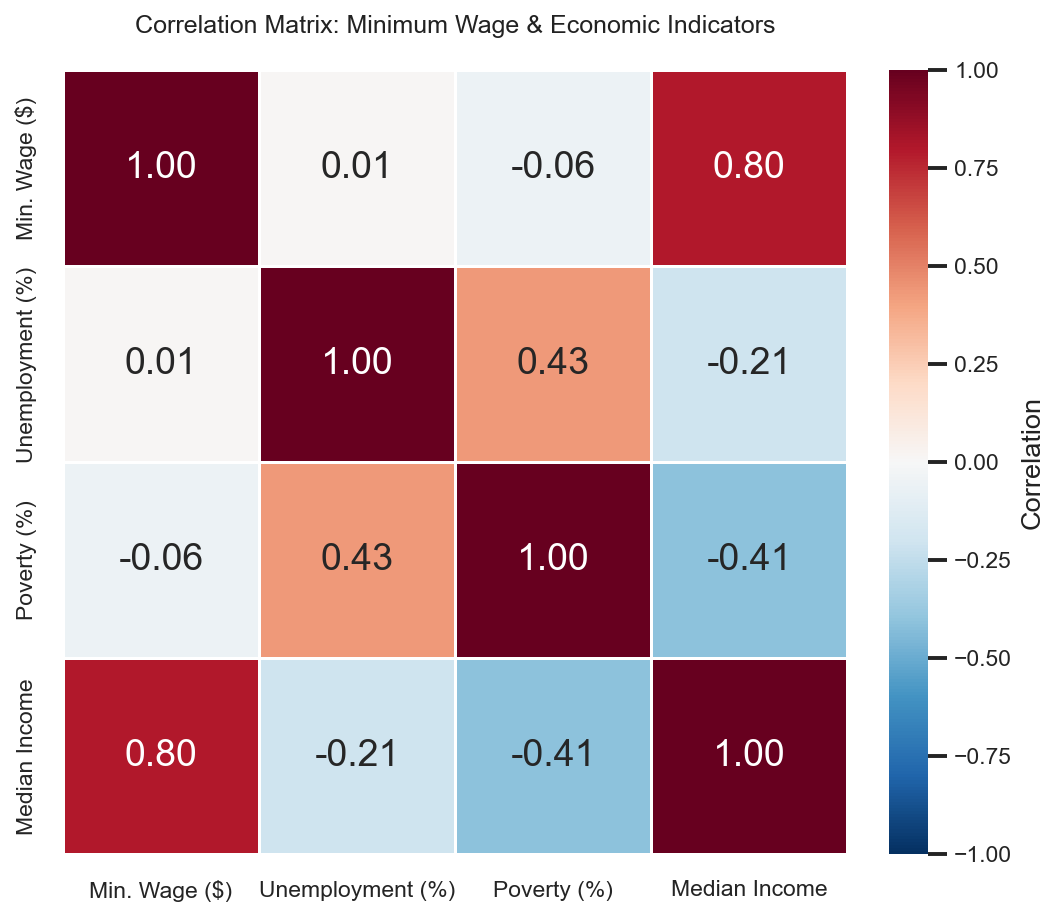

In [7]:
#Let's take a look at a raw correlation heatmap of these variables

label_map = {
    'effective_min_wage': 'Min. Wage ($)',
    'pct_unemployed': 'Unemployment (%)',
    'pct_poverty': 'Poverty (%)',
    'median_income': 'Median Income'
}

corr_matrix = panel[list(label_map.keys())].rename(columns=label_map).corr()

plt.figure(figsize=(7, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',       # diverging cmap
    center=0,            # anchors white at 0, so positive/negative are visually distinct
    vmin=-1, vmax=1,     # locks scale so colors are comparable across your other charts
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)

plt.title('Correlation Matrix: Minimum Wage & Economic Indicators', fontsize=12)
plt.savefig('../figures/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Raw pairwise correlation shows minimum wage has essentially no
# relationship with unemployment (r = 0.01) or poverty (r = -0.06), but a
# strong positive relationship with median income (r = 0.80).
#
# The strong income correlation should be treated with caution. 
# It likely reflects that high-minimum-wage states (CA, MA, NY) also tend to
# be wealthier, more urban, higher-cost-of-living states for reasons that have
# nothing to do with the minimum wage itself.